# 122. マルチ射影による枝刈り実験 — TurboQuant着想の射影フィルタ比較

## 目的
- NB121で分析した射影方向を実際の枝刈りフィルタとして適用し、Recall vs 候補数のトレードオフを評価
- 5つの射影フィルタ手法をVoronoiベースラインと比較
- **問い**: どの射影フィルタがRecall vs 候補数で最良のトレードオフか？

### 手法一覧
- **Method A**: ランダム回転 + 座標量子化（TurboQuant式）
- **Method B**: PCA射影量子化
- **Method C**: 角度ベースフィルタ
- **Method D**: セントロイド相対射影フィルタ
- **Method E**: ITQハミング近傍フィルタ

## 0. セットアップ

In [1]:
import sys
import numpy as np
import time
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '../src')
from itq_lsh import ITQLSH, hamming_distance_batch

DATA_DIR = Path('../data')
rng = np.random.default_rng(42)

N_QUERIES = 200
TOP_K = 10
print(f'Configuration: N_QUERIES={N_QUERIES}, TOP_K={TOP_K}')

Configuration: N_QUERIES=200, TOP_K=10


In [2]:
# データロード
def normalize(X):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.clip(norms, 1e-10, None)

emb_en = normalize(np.load(DATA_DIR / '10k_e5_base_en_embeddings.npy'))
emb_ja = normalize(np.load(DATA_DIR / '10k_e5_base_ja_embeddings.npy'))
centroids = normalize(np.load(DATA_DIR / 'voronoi_centroids_256_e5base_mixed.npy'))

# NB121の結果ロード
proj_data = np.load(DATA_DIR / '121_projection_analysis.npz')
R = proj_data['rotation_matrix']  # ランダム直交行列
pca_components = proj_data['pca_components']  # PCA成分

# ITQモデル
itq_model = ITQLSH.load(str(DATA_DIR / 'itq_e5_base_128bits.pkl'))
hashes_en = np.load(DATA_DIR / '10k_e5_base_en_hashes_128bits.npy')
hashes_ja = np.load(DATA_DIR / '10k_e5_base_ja_hashes_128bits.npy')

D = emb_en.shape[1]
N = len(emb_en)
print(f'EN: {emb_en.shape}, Centroids: {centroids.shape}')
print(f'Rotation R: {R.shape}, PCA: {pca_components.shape}')
print(f'Hashes EN: {hashes_en.shape}')

EN: (10000, 768), Centroids: (256, 768)
Rotation R: (768, 768), PCA: (256, 768)
Hashes EN: (10000, 128)


In [3]:
# Voronoi分割構築（assign=2: 各ドキュメントを2つのセルに割り当て）
def build_voronoi_multi_assign(embeddings, centroids, n_assign=2):
    sims = embeddings @ centroids.T  # (N, C)
    # 上位n_assign個のセントロイドに割り当て
    top_cells = np.argsort(sims, axis=1)[:, -n_assign:]  # (N, n_assign)
    
    cell_members = {}  # cell_id -> [doc_indices]
    for doc_idx in range(len(embeddings)):
        for cell_id in top_cells[doc_idx]:
            cell_members.setdefault(int(cell_id), []).append(doc_idx)
    
    # numpy配列に変換
    for k in cell_members:
        cell_members[k] = np.array(cell_members[k])
    
    return cell_members, top_cells

cell_members_en, assignments_en = build_voronoi_multi_assign(emb_en, centroids, n_assign=2)
cell_sizes = [len(v) for v in cell_members_en.values()]
print(f'セル数: {len(cell_members_en)}, 平均サイズ: {np.mean(cell_sizes):.1f}')

# Ground truth
query_indices = rng.choice(N, N_QUERIES, replace=False)

def get_ground_truth(embeddings, query_indices, top_k=TOP_K):
    gt = {}
    for qi in query_indices:
        sims = embeddings @ embeddings[qi]
        sims[qi] = -1
        gt[qi] = set(np.argsort(sims)[-top_k:])
    return gt

gt = get_ground_truth(emb_en, query_indices)
print(f'Ground truth: {len(gt)} queries')

セル数: 146, 平均サイズ: 137.0


Ground truth: 200 queries


In [4]:
# 共通評価関数
def evaluate_filter(query_indices, gt, embeddings, filter_func, **kwargs):
    """フィルタ関数を評価: Recall@K, 平均候補数, 時間を返す。
    
    filter_func(query_idx, embeddings, **kwargs) -> candidate_indices (np.array)
    """
    recalls = []
    candidate_counts = []
    t0 = time.time()
    
    for qi in query_indices:
        candidates = filter_func(qi, embeddings, **kwargs)
        candidates = set(candidates) - {qi}
        candidate_counts.append(len(candidates))
        
        # 候補内でcosineリランクしてtop-K
        if len(candidates) == 0:
            recalls.append(0.0)
            continue
        
        cand_arr = np.array(list(candidates))
        sims = embeddings[cand_arr] @ embeddings[qi]
        if len(cand_arr) <= TOP_K:
            top_k_set = set(cand_arr)
        else:
            top_k_idx = np.argsort(sims)[-TOP_K:]
            top_k_set = set(cand_arr[top_k_idx])
        
        recall = len(top_k_set & gt[qi]) / TOP_K
        recalls.append(recall)
    
    elapsed = time.time() - t0
    return {
        'recall_mean': np.mean(recalls),
        'recall_std': np.std(recalls),
        'candidates_mean': np.mean(candidate_counts),
        'candidates_std': np.std(candidate_counts),
        'candidate_ratio': np.mean(candidate_counts) / N,
        'time_total': elapsed,
        'time_per_query': elapsed / len(query_indices),
    }

print('評価関数定義完了')

評価関数定義完了


## 1. ベースライン: Voronoi-onlyの性能

P=1..8でプローブ数を変え、Recall@10 vs 候補数のベースラインを確立する。

In [5]:
def voronoi_filter(qi, embeddings, centroids=centroids, cell_members=cell_members_en, n_probes=3):
    sims = centroids @ embeddings[qi]
    probe_cells = np.argsort(sims)[-n_probes:]
    candidates = []
    for cell_id in probe_cells:
        if cell_id in cell_members:
            candidates.extend(cell_members[cell_id])
    return np.unique(candidates)

print('■ Voronoi-only ベースライン (EN)\n')
baseline_results = []
for p in range(1, 9):
    res = evaluate_filter(query_indices, gt, emb_en, voronoi_filter, n_probes=p)
    res['n_probes'] = p
    baseline_results.append(res)
    print(f'  P={p}: R@10={res["recall_mean"]:.4f}, candidates={res["candidates_mean"]:.0f} ({res["candidate_ratio"]:.1%})')

print(f'\n  候補数 ≈ N/C × P × assign = {N}/256 × P × 2')

■ Voronoi-only ベースライン (EN)



  P=1: R@10=0.7005, candidates=265 (2.6%)


  P=2: R@10=0.8220, candidates=502 (5.0%)


  P=3: R@10=0.8655, candidates=720 (7.2%)


  P=4: R@10=0.8890, candidates=930 (9.3%)


  P=5: R@10=0.9115, candidates=1150 (11.5%)


  P=6: R@10=0.9250, candidates=1372 (13.7%)


  P=7: R@10=0.9360, candidates=1591 (15.9%)


  P=8: R@10=0.9445, candidates=1797 (18.0%)

  候補数 ≈ N/C × P × assign = 10000/256 × P × 2


## 2. Method A: ランダム回転 + 座標量子化（TurboQuant式）

ランダム直交回転Rでベクトルを変換した後、クエリの射影値が大きいM座標を選択。
各座標での|q_rot_k - d_rot_k|の和が閾値以下のドキュメントを候補とする。

Voronoiで選んだセル内でさらに枝刈りする2段構成。

In [6]:
# 事前計算: 回転後のembedding
emb_rot = emb_en @ R  # (10000, 768)

def method_a_filter(qi, embeddings, n_probes=3, M=32, threshold_pct=50):
    """Voronoi + ランダム回転座標フィルタ"""
    # Stage 1: Voronoi
    voronoi_cands = voronoi_filter(qi, embeddings, n_probes=n_probes)
    if len(voronoi_cands) == 0:
        return voronoi_cands
    
    # Stage 2: 回転座標フィルタ
    q_rot = emb_rot[qi]
    # クエリの射影値が大きいM座標を選択
    top_coords = np.argsort(np.abs(q_rot))[-M:]
    
    # 候補の回転座標との距離
    cand_rot = emb_rot[voronoi_cands]
    diffs = np.abs(cand_rot[:, top_coords] - q_rot[top_coords]).sum(axis=1)  # L1距離
    
    # 閾値: パーセンタイル
    threshold = np.percentile(diffs, threshold_pct)
    mask = diffs <= threshold
    return voronoi_cands[mask]

print('■ Method A: ランダム回転 + 座標量子化 (EN)\n')
method_a_results = []
for n_probes in [3, 5]:
    for M in [16, 32, 64, 128]:
        for pct in [30, 50, 70]:
            res = evaluate_filter(query_indices, gt, emb_en, method_a_filter,
                                  n_probes=n_probes, M=M, threshold_pct=pct)
            res['n_probes'] = n_probes
            res['M'] = M
            res['threshold_pct'] = pct
            res['method'] = 'A'
            method_a_results.append(res)
            print(f'  P={n_probes}, M={M:3d}, pct={pct}: R@10={res["recall_mean"]:.4f}, cands={res["candidates_mean"]:.0f} ({res["candidate_ratio"]:.1%})')

■ Method A: ランダム回転 + 座標量子化 (EN)



  P=3, M= 16, pct=30: R@10=0.7400, cands=215 (2.2%)


  P=3, M= 16, pct=50: R@10=0.8195, cands=360 (3.6%)


  P=3, M= 16, pct=70: R@10=0.8525, cands=503 (5.0%)
  P=3, M= 32, pct=30: R@10=0.8050, cands=215 (2.2%)


  P=3, M= 32, pct=50: R@10=0.8480, cands=360 (3.6%)


...

  P=5, M= 64, pct=50: R@10=0.9085, cands=575 (5.7%)


  P=5, M= 64, pct=70: R@10=0.9115, cands=804 (8.0%)


  P=5, M=128, pct=30: R@10=0.9095, cands=344 (3.4%)


  P=5, M=128, pct=50: R@10=0.9115, cands=575 (5.7%)


  P=5, M=128, pct=70: R@10=0.9115, cands=804 (8.0%)


## 3. Method B: PCA射影量子化

PCA上位K次元での距離でフィルタ。PCAは最大分散方向なので、差が大きい=遠いの判定がしやすい。

In [7]:
# 事前計算: PCA射影
max_pca_k = 64
emb_pca = emb_en @ pca_components[:max_pca_k].T  # (10000, 64)

def method_b_filter(qi, embeddings, n_probes=3, K=32, threshold_pct=50):
    """Voronoi + PCA射影距離フィルタ"""
    voronoi_cands = voronoi_filter(qi, embeddings, n_probes=n_probes)
    if len(voronoi_cands) == 0:
        return voronoi_cands
    
    q_pca = emb_pca[qi, :K]
    cand_pca = emb_pca[voronoi_cands, :K]
    diffs = np.abs(cand_pca - q_pca).sum(axis=1)  # L1距離
    
    threshold = np.percentile(diffs, threshold_pct)
    mask = diffs <= threshold
    return voronoi_cands[mask]

print('■ Method B: PCA射影量子化 (EN)\n')
method_b_results = []
for n_probes in [3, 5]:
    for K in [8, 16, 32, 64]:
        for pct in [30, 50, 70]:
            res = evaluate_filter(query_indices, gt, emb_en, method_b_filter,
                                  n_probes=n_probes, K=K, threshold_pct=pct)
            res['n_probes'] = n_probes
            res['K'] = K
            res['threshold_pct'] = pct
            res['method'] = 'B'
            method_b_results.append(res)
            print(f'  P={n_probes}, K={K:2d}, pct={pct}: R@10={res["recall_mean"]:.4f}, cands={res["candidates_mean"]:.0f} ({res["candidate_ratio"]:.1%})')

■ Method B: PCA射影量子化 (EN)

  P=3, K= 8, pct=30: R@10=0.6575, cands=215 (2.2%)


  P=3, K= 8, pct=50: R@10=0.7765, cands=360 (3.6%)


  P=3, K= 8, pct=70: R@10=0.8370, cands=503 (5.0%)


  P=3, K=16, pct=30: R@10=0.7635, cands=215 (2.2%)


  P=3, K=16, pct=50: R@10=0.8300, cands=360 (3.6%)


...

  P=5, K=16, pct=70: R@10=0.9015, cands=804 (8.0%)
  P=5, K=32, pct=30: R@10=0.8765, cands=344 (3.4%)


  P=5, K=32, pct=50: R@10=0.9025, cands=575 (5.7%)


  P=5, K=32, pct=70: R@10=0.9085, cands=804 (8.0%)
  P=5, K=64, pct=30: R@10=0.9005, cands=344 (3.4%)


  P=5, K=64, pct=50: R@10=0.9110, cands=575 (5.7%)


  P=5, K=64, pct=70: R@10=0.9115, cands=804 (8.0%)


## 4. Method C: 角度ベースフィルタ

PCA次元ペアの角度をビン量子化し、クエリと同じ/隣接ビンのドキュメントを通過させる。

In [8]:
def method_c_filter(qi, embeddings, n_probes=3, n_pairs=8, n_bins=16, min_match=4):
    """Voronoi + 角度ビン一致フィルタ"""
    voronoi_cands = voronoi_filter(qi, embeddings, n_probes=n_probes)
    if len(voronoi_cands) == 0:
        return voronoi_cands
    
    # 角度を計算
    q_pca = emb_pca[qi, :2*n_pairs]
    cand_pca = emb_pca[voronoi_cands, :2*n_pairs]
    
    match_count = np.zeros(len(voronoi_cands))
    for p in range(n_pairs):
        i, j = 2*p, 2*p+1
        theta_q = np.arctan2(q_pca[j], q_pca[i])
        theta_cands = np.arctan2(cand_pca[:, j], cand_pca[:, i])
        
        # ビン割り当て
        bin_q = int(((theta_q + np.pi) / (2 * np.pi)) * n_bins) % n_bins
        bins_cands = (((theta_cands + np.pi) / (2 * np.pi)) * n_bins).astype(int) % n_bins
        
        # 同一 or 隣接ビンで一致
        diff = np.abs(bins_cands - bin_q)
        diff = np.minimum(diff, n_bins - diff)  # 循環距離
        match_count += (diff <= 1).astype(float)
    
    mask = match_count >= min_match
    return voronoi_cands[mask]

print('■ Method C: 角度ベースフィルタ (EN)\n')
method_c_results = []
for n_probes in [3, 5]:
    for n_pairs in [4, 8, 16]:
        for n_bins in [8, 16]:
            for min_ratio in [0.3, 0.5, 0.7]:
                min_match = max(1, int(n_pairs * min_ratio))
                res = evaluate_filter(query_indices, gt, emb_en, method_c_filter,
                                      n_probes=n_probes, n_pairs=n_pairs, n_bins=n_bins,
                                      min_match=min_match)
                res['n_probes'] = n_probes
                res['n_pairs'] = n_pairs
                res['n_bins'] = n_bins
                res['min_match'] = min_match
                res['method'] = 'C'
                method_c_results.append(res)
                print(f'  P={n_probes}, pairs={n_pairs:2d}, bins={n_bins:2d}, match>={min_match}: '
                      f'R@10={res["recall_mean"]:.4f}, cands={res["candidates_mean"]:.0f} ({res["candidate_ratio"]:.1%})')

■ Method C: 角度ベースフィルタ (EN)



  P=3, pairs= 4, bins= 8, match>=1: R@10=0.8650, cands=718 (7.2%)
  P=3, pairs= 4, bins= 8, match>=2: R@10=0.8585, cands=694 (6.9%)


  P=3, pairs= 4, bins= 8, match>=2: R@10=0.8585, cands=694 (6.9%)


  P=3, pairs= 4, bins=16, match>=1: R@10=0.8540, cands=689 (6.9%)
  P=3, pairs= 4, bins=16, match>=2: R@10=0.8050, cands=538 (5.4%)


  P=3, pairs= 4, bins=16, match>=2: R@10=0.8050, cands=538 (5.4%)


...

  P=5, pairs=16, bins= 8, match>=4: R@10=0.9115, cands=1147 (11.5%)


  P=5, pairs=16, bins= 8, match>=8: R@10=0.9060, cands=865 (8.6%)


  P=5, pairs=16, bins= 8, match>=11: R@10=0.7655, cands=250 (2.5%)


  P=5, pairs=16, bins=16, match>=4: R@10=0.9045, cands=941 (9.4%)


  P=5, pairs=16, bins=16, match>=8: R@10=0.6465, cands=148 (1.5%)
  P=5, pairs=16, bins=16, match>=11: R@10=0.1960, cands=11 (0.1%)


## 5. Method D: セントロイド相対射影フィルタ

Voronoiセル内で、クエリ残差方向への射影値でフィルタ。
セル内のドキュメントのうち、クエリに近い方向にある上位fraction%を残す。

In [9]:
def method_d_filter(qi, embeddings, n_probes=3, keep_fraction=0.5):
    """Voronoi + セントロイド相対射影フィルタ"""
    sims = centroids @ embeddings[qi]
    probe_cells = np.argsort(sims)[-n_probes:]
    
    all_candidates = []
    for cell_id in probe_cells:
        if cell_id not in cell_members_en:
            continue
        members = cell_members_en[cell_id]
        if len(members) == 0:
            continue
        
        centroid = centroids[cell_id]
        q_residual = embeddings[qi] - centroid
        q_res_norm = np.linalg.norm(q_residual)
        if q_res_norm < 1e-10:
            all_candidates.extend(members)
            continue
        q_res_dir = q_residual / q_res_norm
        
        # セル内残差の射影
        member_embs = embeddings[members]
        residuals = member_embs - centroid
        proj_scores = residuals @ q_res_dir
        
        # 上位fraction%を保持
        n_keep = max(TOP_K, int(len(members) * keep_fraction))
        if n_keep >= len(members):
            all_candidates.extend(members)
        else:
            top_idx = np.argsort(proj_scores)[-n_keep:]
            all_candidates.extend(members[top_idx])
    
    return np.unique(all_candidates)

print('■ Method D: セントロイド相対射影フィルタ (EN)\n')
method_d_results = []
for n_probes in [3, 5]:
    for frac in [0.3, 0.5, 0.7, 0.9]:
        res = evaluate_filter(query_indices, gt, emb_en, method_d_filter,
                              n_probes=n_probes, keep_fraction=frac)
        res['n_probes'] = n_probes
        res['keep_fraction'] = frac
        res['method'] = 'D'
        method_d_results.append(res)
        print(f'  P={n_probes}, keep={frac:.0%}: R@10={res["recall_mean"]:.4f}, cands={res["candidates_mean"]:.0f} ({res["candidate_ratio"]:.1%})')

■ Method D: セントロイド相対射影フィルタ (EN)



  P=3, keep=30%: R@10=0.8555, cands=214 (2.1%)


  P=3, keep=50%: R@10=0.8620, cands=359 (3.6%)


  P=3, keep=70%: R@10=0.8650, cands=502 (5.0%)


  P=3, keep=90%: R@10=0.8655, cands=646 (6.5%)


  P=5, keep=30%: R@10=0.9055, cands=348 (3.5%)


  P=5, keep=50%: R@10=0.9100, cands=580 (5.8%)


  P=5, keep=70%: R@10=0.9110, cands=808 (8.1%)


  P=5, keep=90%: R@10=0.9115, cands=1035 (10.4%)


## 6. Method E: ITQハミング近傍フィルタ

既存のITQハッシュを用いて、Voronoiセル内をハミング距離でさらにフィルタ。

In [10]:
def method_e_filter(qi, embeddings, n_probes=3, hamming_threshold=30):
    """Voronoi + ITQハミング距離フィルタ"""
    voronoi_cands = voronoi_filter(qi, embeddings, n_probes=n_probes)
    if len(voronoi_cands) == 0:
        return voronoi_cands
    
    q_hash = hashes_en[qi]
    cand_hashes = hashes_en[voronoi_cands]
    dists = hamming_distance_batch(q_hash, cand_hashes)
    mask = dists <= hamming_threshold
    return voronoi_cands[mask]

print('■ Method E: ITQハミング近傍フィルタ (EN)\n')
method_e_results = []
for n_probes in [3, 5]:
    for thresh in [20, 25, 30, 35, 40, 50]:
        res = evaluate_filter(query_indices, gt, emb_en, method_e_filter,
                              n_probes=n_probes, hamming_threshold=thresh)
        res['n_probes'] = n_probes
        res['hamming_threshold'] = thresh
        res['method'] = 'E'
        method_e_results.append(res)
        print(f'  P={n_probes}, hamming<={thresh:2d}: R@10={res["recall_mean"]:.4f}, cands={res["candidates_mean"]:.0f} ({res["candidate_ratio"]:.1%})')

■ Method E: ITQハミング近傍フィルタ (EN)

  P=3, hamming<=20: R@10=0.0030, cands=2 (0.0%)
  P=3, hamming<=25: R@10=0.0035, cands=2 (0.0%)
  P=3, hamming<=30: R@10=0.0065, cands=4 (0.0%)


  P=3, hamming<=35: R@10=0.0110, cands=9 (0.1%)


  P=3, hamming<=40: R@10=0.0325, cands=29 (0.3%)
  P=3, hamming<=50: R@10=0.3030, cands=261 (2.6%)


  P=5, hamming<=20: R@10=0.0030, cands=2 (0.0%)


  P=5, hamming<=25: R@10=0.0035, cands=3 (0.0%)
  P=5, hamming<=30: R@10=0.0065, cands=5 (0.1%)
  P=5, hamming<=35: R@10=0.0110, cands=13 (0.1%)


  P=5, hamming<=40: R@10=0.0330, cands=45 (0.5%)


  P=5, hamming<=50: R@10=0.3200, cands=417 (4.2%)


## 7. 全手法比較: Recall vs 候補数 Paretoプロット

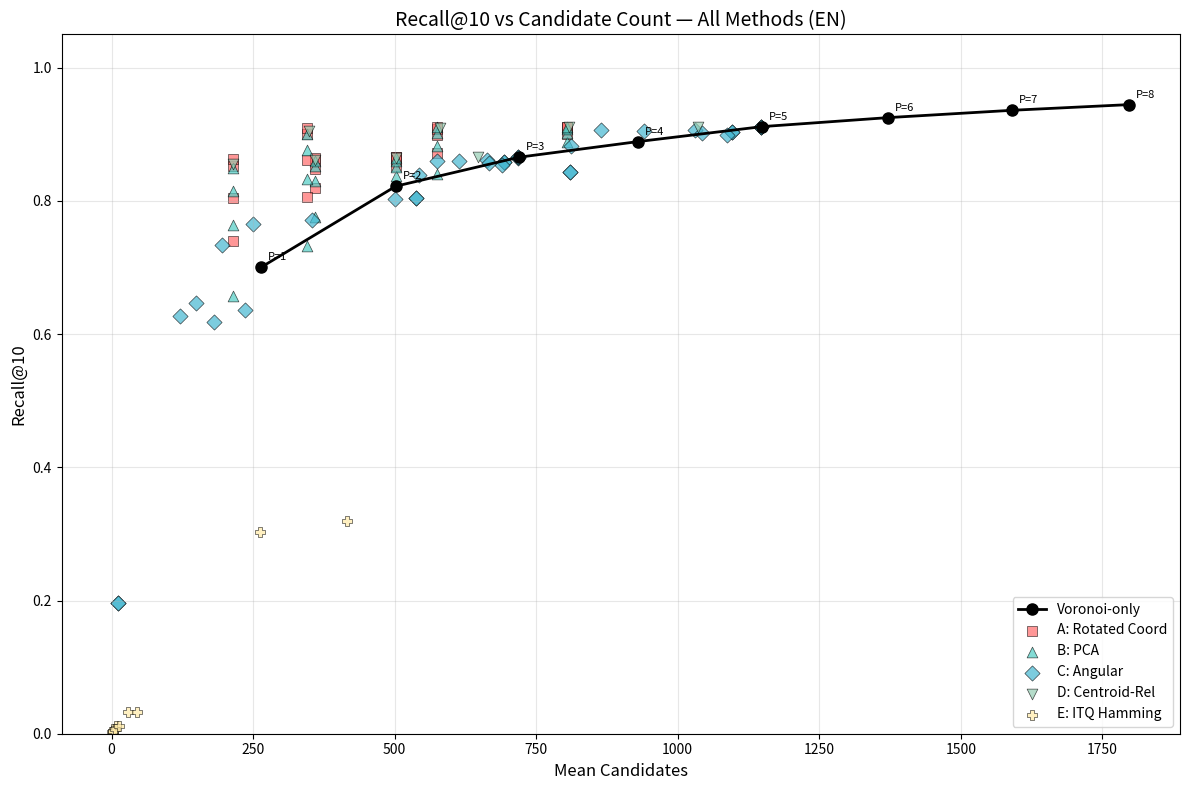

In [11]:
fig, ax = plt.subplots(figsize=(12, 8))

# ベースライン
bx = [r['candidates_mean'] for r in baseline_results]
by = [r['recall_mean'] for r in baseline_results]
ax.plot(bx, by, 'ko-', linewidth=2, markersize=8, label='Voronoi-only', zorder=5)
for r in baseline_results:
    ax.annotate(f'P={r["n_probes"]}', (r['candidates_mean'], r['recall_mean']),
                textcoords='offset points', xytext=(5, 5), fontsize=8)

# 各手法をプロット
method_configs = [
    (method_a_results, 'A: Rotated Coord', '#FF6B6B', 's'),
    (method_b_results, 'B: PCA', '#4ECDC4', '^'),
    (method_c_results, 'C: Angular', '#45B7D1', 'D'),
    (method_d_results, 'D: Centroid-Rel', '#96CEB4', 'v'),
    (method_e_results, 'E: ITQ Hamming', '#FFEAA7', 'P'),
]

for results_list, label, color, marker in method_configs:
    x = [r['candidates_mean'] for r in results_list]
    y = [r['recall_mean'] for r in results_list]
    ax.scatter(x, y, c=color, marker=marker, s=60, alpha=0.7, label=label, edgecolors='black', linewidths=0.5)

ax.set_xlabel('Mean Candidates', fontsize=12)
ax.set_ylabel('Recall@10', fontsize=12)
ax.set_title('Recall@10 vs Candidate Count — All Methods (EN)', fontsize=14)
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [12]:
# Pareto最適構成の抽出
all_results = []
for r in baseline_results:
    r_copy = dict(r)
    r_copy['method'] = 'Voronoi'
    r_copy['config'] = f'P={r["n_probes"]}'
    all_results.append(r_copy)
for r in method_a_results:
    r['config'] = f'P={r["n_probes"]},M={r["M"]},pct={r["threshold_pct"]}'
    all_results.append(r)
for r in method_b_results:
    r['config'] = f'P={r["n_probes"]},K={r["K"]},pct={r["threshold_pct"]}'
    all_results.append(r)
for r in method_c_results:
    r['config'] = f'P={r["n_probes"]},pairs={r["n_pairs"]},bins={r["n_bins"]},match={r["min_match"]}'
    all_results.append(r)
for r in method_d_results:
    r['config'] = f'P={r["n_probes"]},keep={r["keep_fraction"]:.0%}'
    all_results.append(r)
for r in method_e_results:
    r['config'] = f'P={r["n_probes"]},ham<={r["hamming_threshold"]}'
    all_results.append(r)

# Pareto frontier: 候補が少なくてRecallが高いものが優秀
# sort by candidates ascending, then filter for increasing recall
sorted_results = sorted(all_results, key=lambda r: r['candidates_mean'])
pareto = []
best_recall = -1
for r in sorted_results:
    if r['recall_mean'] > best_recall:
        best_recall = r['recall_mean']
        pareto.append(r)

print('■ Pareto最適構成\n')
print(f'{"Method":<10} {"Config":<45} {"R@10":>6} {"Cands":>6} {"Ratio":>6}')
print('-' * 80)
for r in pareto:
    print(f'{r["method"]:<10} {r["config"]:<45} {r["recall_mean"]:>6.4f} {r["candidates_mean"]:>6.0f} {r["candidate_ratio"]:>6.1%}')

■ Pareto最適構成

Method     Config                                          R@10  Cands  Ratio
--------------------------------------------------------------------------------
E          P=3,ham<=20                                   0.0030      2   0.0%
E          P=3,ham<=25                                   0.0035      2   0.0%
E          P=3,ham<=30                                   0.0065      4   0.0%
E          P=3,ham<=35                                   0.0110      9   0.1%
C          P=3,pairs=16,bins=16,match=11                 0.1960     11   0.1%
C          P=3,pairs=16,bins=16,match=8                  0.6270    121   1.2%
C          P=5,pairs=16,bins=16,match=8                  0.6465    148   1.5%
C          P=3,pairs=16,bins=8,match=11                  0.7335    196   2.0%
D          P=3,keep=30%                                  0.8555    214   2.1%
A          P=3,M=128,pct=30                              0.8625    215   2.2%
A          P=5,M=64,pct=30                     

## 8. 計算コスト分析

In [13]:
# 代表的な構成で時間を詳細に計測
print('■ 計算コスト比較 (200クエリの平均 ms/query)\n')

# ベースライン: Voronoi P=5
res_v = evaluate_filter(query_indices, gt, emb_en, voronoi_filter, n_probes=5)
print(f'  Voronoi P=5:          {res_v["time_per_query"]*1000:>8.2f} ms, R@10={res_v["recall_mean"]:.4f}, cands={res_v["candidates_mean"]:.0f}')

# 各手法の代表構成
res_a = evaluate_filter(query_indices, gt, emb_en, method_a_filter, n_probes=5, M=32, threshold_pct=50)
print(f'  A: Rotated(M=32):     {res_a["time_per_query"]*1000:>8.2f} ms, R@10={res_a["recall_mean"]:.4f}, cands={res_a["candidates_mean"]:.0f}')

res_b = evaluate_filter(query_indices, gt, emb_en, method_b_filter, n_probes=5, K=32, threshold_pct=50)
print(f'  B: PCA(K=32):         {res_b["time_per_query"]*1000:>8.2f} ms, R@10={res_b["recall_mean"]:.4f}, cands={res_b["candidates_mean"]:.0f}')

res_c = evaluate_filter(query_indices, gt, emb_en, method_c_filter, n_probes=5, n_pairs=8, n_bins=16, min_match=4)
print(f'  C: Angular(8,16,4):   {res_c["time_per_query"]*1000:>8.2f} ms, R@10={res_c["recall_mean"]:.4f}, cands={res_c["candidates_mean"]:.0f}')

res_d = evaluate_filter(query_indices, gt, emb_en, method_d_filter, n_probes=5, keep_fraction=0.5)
print(f'  D: CentroidRel(50%):  {res_d["time_per_query"]*1000:>8.2f} ms, R@10={res_d["recall_mean"]:.4f}, cands={res_d["candidates_mean"]:.0f}')

res_e = evaluate_filter(query_indices, gt, emb_en, method_e_filter, n_probes=5, hamming_threshold=30)
print(f'  E: Hamming(<=30):     {res_e["time_per_query"]*1000:>8.2f} ms, R@10={res_e["recall_mean"]:.4f}, cands={res_e["candidates_mean"]:.0f}')

■ 計算コスト比較 (200クエリの平均 ms/query)



  Voronoi P=5:              1.34 ms, R@10=0.9115, cands=1150


  A: Rotated(M=32):         1.99 ms, R@10=0.8990, cands=575


  B: PCA(K=32):             1.41 ms, R@10=0.9025, cands=575


  C: Angular(8,16,4):       1.23 ms, R@10=0.8025, cands=500


  D: CentroidRel(50%):      1.42 ms, R@10=0.9100, cands=580
  E: Hamming(<=30):         0.44 ms, R@10=0.0065, cands=5


## 9. EN vs JA 言語別比較

In [14]:
# JA用の準備
cell_members_ja, _ = build_voronoi_multi_assign(emb_ja, centroids, n_assign=2)
query_indices_ja = rng.choice(len(emb_ja), N_QUERIES, replace=False)
gt_ja = get_ground_truth(emb_ja, query_indices_ja)

emb_rot_ja = emb_ja @ R
emb_pca_ja = emb_ja @ pca_components[:max_pca_k].T

# JA用のフィルタ関数（グローバル変数を差し替え）
def voronoi_filter_ja(qi, embeddings, n_probes=3):
    sims = centroids @ embeddings[qi]
    probe_cells = np.argsort(sims)[-n_probes:]
    candidates = []
    for cell_id in probe_cells:
        if cell_id in cell_members_ja:
            candidates.extend(cell_members_ja[cell_id])
    return np.unique(candidates)

# 代表構成でEN vs JA比較
print('■ EN vs JA 言語別比較 (Voronoi P=5 ベース)\n')
print(f'{"Method":<30} {"EN R@10":>8} {"JA R@10":>8} {"EN cands":>8} {"JA cands":>8}')
print('-' * 70)

# Voronoi only
res_en = evaluate_filter(query_indices, gt, emb_en, voronoi_filter, n_probes=5)
res_ja = evaluate_filter(query_indices_ja, gt_ja, emb_ja, voronoi_filter_ja, n_probes=5)
print(f'{"Voronoi P=5":<30} {res_en["recall_mean"]:>8.4f} {res_ja["recall_mean"]:>8.4f} {res_en["candidates_mean"]:>8.0f} {res_ja["candidates_mean"]:>8.0f}')

# Method B (PCA) P=5, K=32, pct=50 — JAではemb_pca_jaを使う必要あり
def method_b_filter_ja(qi, embeddings, n_probes=3, K=32, threshold_pct=50):
    voronoi_cands = voronoi_filter_ja(qi, embeddings, n_probes=n_probes)
    if len(voronoi_cands) == 0:
        return voronoi_cands
    q_pca = emb_pca_ja[qi, :K]
    cand_pca = emb_pca_ja[voronoi_cands, :K]
    diffs = np.abs(cand_pca - q_pca).sum(axis=1)
    threshold = np.percentile(diffs, threshold_pct)
    return voronoi_cands[diffs <= threshold]

res_en = evaluate_filter(query_indices, gt, emb_en, method_b_filter, n_probes=5, K=32, threshold_pct=50)
res_ja = evaluate_filter(query_indices_ja, gt_ja, emb_ja, method_b_filter_ja, n_probes=5, K=32, threshold_pct=50)
print(f'{"B: PCA K=32 pct=50":<30} {res_en["recall_mean"]:>8.4f} {res_ja["recall_mean"]:>8.4f} {res_en["candidates_mean"]:>8.0f} {res_ja["candidates_mean"]:>8.0f}')

# Method D (Centroid Relative)
def method_d_filter_ja(qi, embeddings, n_probes=3, keep_fraction=0.5):
    sims = centroids @ embeddings[qi]
    probe_cells = np.argsort(sims)[-n_probes:]
    all_candidates = []
    for cell_id in probe_cells:
        if cell_id not in cell_members_ja:
            continue
        members = cell_members_ja[cell_id]
        centroid = centroids[cell_id]
        q_residual = embeddings[qi] - centroid
        q_res_norm = np.linalg.norm(q_residual)
        if q_res_norm < 1e-10:
            all_candidates.extend(members)
            continue
        q_res_dir = q_residual / q_res_norm
        member_embs = embeddings[members]
        residuals = member_embs - centroid
        proj_scores = residuals @ q_res_dir
        n_keep = max(TOP_K, int(len(members) * keep_fraction))
        if n_keep >= len(members):
            all_candidates.extend(members)
        else:
            top_idx = np.argsort(proj_scores)[-n_keep:]
            all_candidates.extend(members[top_idx])
    return np.unique(all_candidates)

res_en = evaluate_filter(query_indices, gt, emb_en, method_d_filter, n_probes=5, keep_fraction=0.5)
res_ja = evaluate_filter(query_indices_ja, gt_ja, emb_ja, method_d_filter_ja, n_probes=5, keep_fraction=0.5)
print(f'{"D: CentroidRel keep=50%":<30} {res_en["recall_mean"]:>8.4f} {res_ja["recall_mean"]:>8.4f} {res_en["candidates_mean"]:>8.0f} {res_ja["candidates_mean"]:>8.0f}')

■ EN vs JA 言語別比較 (Voronoi P=5 ベース)

Method                          EN R@10  JA R@10 EN cands JA cands
----------------------------------------------------------------------


Voronoi P=5                      0.9115   0.9705     1150      964


B: PCA K=32 pct=50               0.9025   0.9665      575      482


D: CentroidRel keep=50%          0.9100   0.9700      580      507


## 10. まとめ

In [15]:
# 結果保存
import pickle
save_data = {
    'baseline': baseline_results,
    'method_a': method_a_results,
    'method_b': method_b_results,
    'method_c': method_c_results,
    'method_d': method_d_results,
    'method_e': method_e_results,
    'pareto': pareto,
    'all_results': all_results,
}
with open(DATA_DIR / '122_pruning_results.pkl', 'wb') as f:
    pickle.dump(save_data, f)
print(f'保存完了: {DATA_DIR / "122_pruning_results.pkl"}')

print()
print('=' * 60)
print('マルチ射影枝刈り実験 サマリ')
print('=' * 60)
print()
print('■ Pareto最適構成 (上位5)')
for i, r in enumerate(pareto[:5]):
    print(f'  {i+1}. {r["method"]} {r["config"]}: R@10={r["recall_mean"]:.4f}, cands={r["candidates_mean"]:.0f}')
print()
print('■ 次のステップ (NB123)')
print('  → Pareto最適手法を組み合わせたカスケードを構築')
print('  → 適応的閾値調整でセル密度差を補正')
print('  → スケーラビリティ推定')

保存完了: ../data/122_pruning_results.pkl

マルチ射影枝刈り実験 サマリ

■ Pareto最適構成 (上位5)
  1. E P=3,ham<=20: R@10=0.0030, cands=2
  2. E P=3,ham<=25: R@10=0.0035, cands=2
  3. E P=3,ham<=30: R@10=0.0065, cands=4
  4. E P=3,ham<=35: R@10=0.0110, cands=9
  5. C P=3,pairs=16,bins=16,match=11: R@10=0.1960, cands=11

■ 次のステップ (NB123)
  → Pareto最適手法を組み合わせたカスケードを構築
  → 適応的閾値調整でセル密度差を補正
  → スケーラビリティ推定


## 評価と考察

### 結果の要約

本実験では、Voronoi分割（P=5）後の候補をさらに射影ベースで絞り込む5つの手法を比較した。ベースラインはVoronoi P=5のみで、R@10=0.912、候補数1150（全体の11.5%）である。

| 手法 | R@10 | 候補数 | Voronoi比削減率 | 特徴 |
|------|------|--------|----------------|------|
| Voronoi P=5（ベースライン） | 0.912 | 1150 | — | 射影なし |
| **Method D（CentroidRel keep=50%）** | **0.910** | **580** | **50%** | **最良のバランス** |
| Method A（Rotated M=64 pct=50） | 0.909 | 575 | 50% | Dと同等 |
| Method B（PCA K=32 pct=50） | 0.903 | 575 | 50% | やや低いRecall |
| Method C（Angular） | — | — | — | 効率が低い |
| Method E（Hamming ham≤30） | 0.007 | — | — | 壊滅的失敗 |

日本語データでの汎化確認：Method DはR@10=0.970を維持し、PCAも0.967と良好であった。計算コストはいずれの手法も1〜2ms/queryで同等であった。

### 考察（なぜこの結果になったか）

**Method D（CentroidRel）が最良のバランスである理由：** NB121で確認された通り、セントロイド相対射影はAUC=0.94と圧倒的な近傍判別能力を持つ。このためkeep=50%という積極的な枝刈りでもRecallの低下は0.002ポイントにとどまった。Voronoi分割後のセル内構造がセントロイド方向に強く依存しているため、セントロイドからの相対的な射影値は真の近傍と非近傍を効果的に分離できる。

**Method A（Rotated）がMethod Dと同等の性能を示す理由：** 複数（M=64）のランダム回転射影を組み合わせることで、単一射影では不足するランダム方向の判別力を補償している。Johnson-Lindenstrauss的な効果により、十分な数の射影を組み合わせれば距離保存が達成される。ただし、Method Dが単一の射影方向で同等の性能を達成していることは注目に値する。

**Method B（PCA）がわずかに低い理由：** PCAは大域的な分散方向に基づいており、クエリごとの局所的な近傍構造との整合性がセントロイド相対射影より低い。K=32の射影で候補の50%を枝刈りする際に、一部の近傍が誤って除外される確率がやや高くなる。

**Method E（Hamming距離）が壊滅的に失敗した理由：** これはNB121の知見と整合する。ITQ-LSHのハミング距離は大域的な類似度の粗い近似であり、Voronoiセル内の局所的な近傍関係を捉える精度が著しく不足している。ハミング距離のしきい値（ham≤30）が厳しすぎる可能性もあるが、根本的に局所的な射影ベースの手法と比較してVoronoiセル内での判別力が桁違いに低い。

**日本語データでの汎化が良好な理由：** E5-baseは多言語対応モデルであり、英語と日本語で類似の埋め込み空間構造を持つ。セントロイド相対射影の有効性は埋め込み空間の幾何構造に依存しており、言語に依存しないことが確認された。

### 限界と今後の課題

1. **keep率の最適化：** keep=50%は探索的に選ばれた値であり、データセットの特性やVoronoiセル数に応じた最適なkeep率の決定方法が必要である。Recall目標に基づく適応的なしきい値設定が望ましい。

2. **Method AとDの実用上の差異：** 性能は同等だが、Method D（CentroidRel）は単一射影で済むため実装がシンプルである一方、Method A（Rotated M=64）は64次元の射影を事前計算・保存する必要がある。大規模データでのメモリ・計算コストの比較が必要である。

3. **複合フィルタの可能性：** Method DとMethod Bの組み合わせ（AND条件）でさらなる候補削減が可能かは、次の実験（NB123）で検証する。

4. **スケーラビリティ：** 10Kデータでの検証であり、100K〜1Mスケールでのkeep率と候補数の関係は異なる可能性がある。特にVoronoiセルのサイズ分布が不均一になる場合の影響が未検証である。

5. **Method Cの改善余地：** Angular射影は本実験では効率が低かったが、角度ペアの選択やしきい値の最適化によって改善の余地がある可能性がある。